# Deep Learning Day 3: Convolutional Neural Networks (CNNs)

## The Big Picture

On Day 1, you built neural networks from the ground up - perceptrons, activations, hidden layers - and even a Dense network that reads handwritten digits. It worked, but it treated each image as a flat list of pixels. That's its secret limitation: **plain Dense networks struggle with real images**.

Today, we fix that. You'll learn **Convolutional Neural Networks (CNNs)** - the architecture that powers:
- Face ID on your phone
- Google Photos search
- Medical image diagnosis
- Self-driving car vision
- And almost every image AI you've ever used

By the end of today, you'll understand WHY regular networks fail on images, HOW CNNs solve the problem, and you'll BUILD your own image classifier from scratch.

## Learning Objectives

By the end of this lecture, you will:
- Understand WHY images need special treatment (CNNs vs Dense networks)
- Know how convolutional layers detect patterns (filters, feature maps)
- Build CNN architectures with Conv2D, MaxPool2D, and Flatten
- Classify images into multiple categories (multi-class with softmax)
- Load image datasets from folder structures
- Apply data augmentation to prevent overfitting
- Evaluate models with confusion matrices and classification reports

## Your Journey So Far

```
ML Week:     Logistic Regression, Decision Trees, Random Forest
             |
DL Day 1:    Perceptrons, Activations, Hidden Layers, Forward Pass,
             your first Dense network on MNIST digits
                       |
             +---------+-----------+
             |                     |
DL Day 2:                    DL Day 3:  CNNs for Images
Optimizers, Training,        <- YOU ARE HERE (Today!)
Overfitting                  Both build directly on Day 1
             |
NEXT:        Transfer Learning, Real-World Projects
```

Day 2 and Day 3 are siblings: each picks up the network you built on Day 1 and
takes it further - Day 2 into *how* networks train, Day 3 into *seeing images*.
You do **not** need Day 2 for today.

---

## Setup

### 🎮 Companion App: Convolution Explorer

Throughout this lecture, we'll reference an **interactive visualization app** that brings CNN concepts to life. Open a separate terminal and run:

```bash
cd convolution_explorer && python main.py
```

**Keep it running alongside this notebook!** When you see 🎮 markers, you can immediately try the concept hands-on. The app includes:
- Live convolution visualization (watch kernels slide across images)
- MaxPooling step-by-step demo
- Data Augmentation preview
- CNN vs Dense parameter comparison
- Full VGG16 layer-by-layer simulation

---

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# For evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Suppress warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print(f"TensorFlow version: {tf.__version__}")
print("Setup complete!")

2026-07-05 22:14:05.212680: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.16.2
Setup complete!


---

# Part 1: Why Do Images Need Special Treatment?

## Quick Review: What You Built on Day 1

On Day 1 your networks took **small inputs**. The perceptron took just 2 numbers:

```
A SMALL NETWORK (Day 1 - like the perceptron):

    Each sample = [x, y]     ->    2 features
    Input shape = (2,)       ->    Very small!

    A tiny model:
    Input(2) -> Dense(8) -> Dense(1, sigmoid)
    -> a handful of parameters, trains in seconds
```

You even ended Day 1 by building a **Dense network for MNIST digits** and it hit
about 98%. So Dense networks *can* do images... on tiny 28x28 digits.

This worked because:
- Small input (just a few numbers, or one small digit)
- Clear features
- Simple patterns

**But what happens with real, larger images?**

---

## The Scale Problem: Images Have MANY Pixels

Let's compare a tiny 2-input network to a simple image:

```
COMPARISON: Features per Sample

┌─────────────────────────────────────────────────────────────────────┐
│  Dataset              Input Size          Features                  │
├─────────────────────────────────────────────────────────────────────┤
│  Perceptron (Day 1)   (x, y)              2                        │
│  MNIST digit          28 × 28 × 1         784                      │
│  Small color image    64 × 64 × 3         12,288                   │
│  Medium image         224 × 224 × 3       150,528                  │
│  HD photo             1920 × 1080 × 3     6,220,800                │
└─────────────────────────────────────────────────────────────────────┘

MNIST is 392× larger than that 2-input network!
A medium image is 75,000× larger!
```

**Why does this matter?**

Remember from Day 1: Dense layers connect EVERY input to EVERY neuron.

```
DENSE LAYER PARAMETER COUNT:

For 2 inputs:   2 inputs × 8 neurons = 16 weights + 8 biases = 24 parameters
For MNIST:      784 inputs × 128 neurons = 100,352 weights + 128 biases = 100,480 parameters!
For 224×224:    150,528 inputs × 128 neurons = 19,267,584 parameters!!!

And that's just the FIRST layer!
```

This creates two problems:
1. **Too many parameters** → slow training, needs tons of data, easy to overfit
2. **Loses spatial structure** → we'll explain this next

---

## The Structure Problem: Flattening Destroys Spatial Information

To feed an image into a Dense network, we have to **flatten** it into a 1D vector:

```
FLATTENING AN IMAGE:

Original Image (4×4):           After Flattening:

    ┌─────────────────┐
    │  1   2   3   4  │         [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    │  5   6   7   8  │   →      
    │  9  10  11  12  │         All pixels become one long list.
    │ 13  14  15  16  │         Position information is LOST!
    └─────────────────┘

WHAT'S WRONG WITH THIS?

In the flat vector:
    • Pixel 1 and Pixel 2 are "neighbors" (positions 0 and 1)
    • Pixel 1 and Pixel 5 are "far apart" (positions 0 and 4)

But in the original image:
    • Pixel 1 and Pixel 5 are actual neighbors (vertically adjacent)!
    • Pixel 4 and Pixel 5 are far apart (opposite sides of a row)!

The Dense network has NO IDEA which pixels are actually next to each other!
```

**Why spatial structure matters:**

```
RECOGNIZING A "7":

    ████████               What makes this a "7"?
         ██                • Horizontal line at TOP
        ██                 • Diagonal line going DOWN-LEFT
       ██                  
      ██                   These are SPATIAL patterns!
                           They depend on pixels being NEXT TO each other.

If we scramble the pixel order, it's no longer a "7"!
But a Dense network after flattening doesn't know the original order.
```

---

## The Translation Problem: Same Object, Different Position

There's one more problem with Dense networks on images:

```
THE SAME "7" IN DIFFERENT POSITIONS:

    Position A:              Position B:              Position C:
    ┌────────────────┐      ┌────────────────┐      ┌────────────────┐
    │████            │      │      ████      │      │            ████│
    │   ██           │      │         ██     │      │              ██│
    │  ██            │      │        ██      │      │             ██ │
    │ ██             │      │       ██       │      │            ██  │
    │                │      │                │      │                │
    └────────────────┘      └────────────────┘      └────────────────┘

To us: These are ALL the digit "7"
To a Dense network: These are COMPLETELY DIFFERENT inputs!

After flattening:
    Position A: [1,1,1,1,0,0,0,...,0,0,1,1,0,...]
    Position B: [0,0,0,0,1,1,1,1,0,...]
    Position C: [0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,...]

The network has to SEPARATELY learn:
    "7 in top-left is a 7"
    "7 in center is a 7"
    "7 in top-right is a 7"
    ... for EVERY possible position!
```

This is incredibly wasteful. We need a better approach.

---

## The Solution: Convolutional Neural Networks (CNNs)

CNNs solve all three problems with two key ideas:

```
┌─────────────────────────────────────────────────────────────────────┐
│  KEY IDEA 1: LOCAL CONNECTIVITY                                    │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  Instead of connecting every pixel to every neuron,                │
│  each neuron only looks at a SMALL LOCAL REGION (e.g., 3×3)       │
│                                                                     │
│  Dense:                         CNN:                                │
│  ┌─────────────┐                ┌─────────────┐                    │
│  │ ● ● ● ● ● ● │  All pixels    │ ● ● ●       │  Only 3×3 region  │
│  │ ● ● ● ● ● ● │  connect to    │ ● ● ●       │  connects to      │
│  │ ● ● ● ● ● ● │  each neuron   │ ● ● ●       │  each neuron      │
│  │ ● ● ● ● ● ● │                │             │                    │
│  └─────────────┘                └─────────────┘                    │
│                                                                     │
│  → Preserves spatial structure (neighbors stay neighbors)          │
│  → Far fewer parameters (9 instead of all pixels)                  │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  KEY IDEA 2: WEIGHT SHARING (Same filter everywhere)               │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  The SAME small filter slides across the ENTIRE image.             │
│  It learns to detect a pattern (like an edge) ANYWHERE.            │
│                                                                     │
│  Filter (3×3):        Slide across image:                          │
│  ┌─────────┐          ┌─────────────────────┐                      │
│  │ 1  0 -1 │          │[█ █ █]              │  Position 1          │
│  │ 1  0 -1 │    →     │ █ █ █               │                      │
│  │ 1  0 -1 │          │   [█ █ █]           │  Position 2          │
│  └─────────┘          │     █ █ █           │                      │
│  (vertical edge       │       [█ █ █]       │  Position 3          │
│   detector)           └─────────────────────┘  ... and so on       │
│                                                                     │
│  → Detects "7" regardless of position (translation invariance)    │
│  → Only 9 parameters for this filter, used everywhere!            │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

---

## Summary: Dense vs CNN for Images

```
┌──────────────────────────┬────────────────────────────────────────┐
│      Dense Network       │         Convolutional Network (CNN)    │
├──────────────────────────┼────────────────────────────────────────┤
│ Flattens image to 1D     │ Keeps 2D structure                     │
│ Loses spatial info       │ Preserves spatial relationships        │
│ Every pixel → every node │ Local regions → each node              │
│ Millions of parameters   │ Shared weights, far fewer parameters  │
│ Must learn each position │ Same filter works everywhere          │
│ Prone to overfitting     │ Better generalization                  │
└──────────────────────────┴────────────────────────────────────────┘

BOTTOM LINE:
    Dense networks CAN work on images (we'll prove it!)
    But CNNs work MUCH better.
```

---

---

# Part 2: CNN Building Blocks

Now that you understand **WHY** Dense networks struggle with images (too many parameters, lose spatial structure, no translation invariance), let's learn **HOW** CNNs solve these problems.

A CNN has three main building blocks. Think of them like LEGO pieces - you'll combine them to build powerful image classifiers:

```
CNN ARCHITECTURE OVERVIEW:

┌──────────────────────────────────────────────────────────────────────────┐
│                                                                          │
│   INPUT        FEATURE EXTRACTION              CLASSIFICATION           │
│   IMAGE        (Learn patterns)                (Make prediction)        │
│                                                                          │
│  ┌──────┐     ┌──────┐    ┌──────┐    ┌──────┐    ┌──────┐    ┌──────┐ │
│  │      │     │Conv2D│    │ Max  │    │Conv2D│    │ Max  │    │Dense │ │
│  │ 28×28│ ──► │      │──► │ Pool │──► │      │──► │ Pool │──► │      │ │
│  │      │     │      │    │      │    │      │    │      │    │10 out│ │
│  └──────┘     └──────┘    └──────┘    └──────┘    └──────┘    └──────┘ │
│                                                        │               │
│                                                        ▼               │
│                                                   ┌────────┐           │
│                                                   │Flatten │           │
│                                                   └────────┘           │
│                                                                          │
│  Block 1: Conv2D → MaxPool     Block 2: Conv2D → MaxPool    Dense head │
│  (detect simple patterns)      (detect complex patterns)    (classify) │
│                                                                          │
└──────────────────────────────────────────────────────────────────────────┘
```

Let's understand each block in detail. By the end, you'll know exactly what each piece does and why it's there.

---

## Block 1: Conv2D - The Pattern Detector

**What it does:** Slides small filters across the image to detect local patterns.

**Analogy:** Imagine looking at an image through a small magnifying glass, and sliding it across. At each position, you check "Does this 3×3 region match the pattern I'm looking for?"

### How Convolution Works (Step by Step)

```
STEP 1: Start with an image and a filter

Image (5×5):              Filter (3×3):
┌─────────────────────┐   ┌─────────────┐
│  1   2   3   0   1  │   │  1   0  -1  │   This filter detects
│  0   1   2   3   1  │   │  1   0  -1  │   VERTICAL EDGES
│  1   0   1   2   0  │   │  1   0  -1  │   (light on left,
│  2   1   0   1   3  │   └─────────────┘    dark on right)
│  1   0   2   1   0  │
└─────────────────────┘


STEP 2: Position filter at top-left corner

┌─────────────────────┐
│[1   2   3]  0   1  │   Multiply element-wise and sum:
│[0   1   2]  3   1  │   
│[1   0   1]  2   0  │   (1×1)+(2×0)+(3×-1) + (0×1)+(1×0)+(2×-1) + (1×1)+(0×0)+(1×-1)
│ 2   1   0   1   3  │   = 1 + 0 + (-3) + 0 + 0 + (-2) + 1 + 0 + (-1)
│ 1   0   2   1   0  │   = -4
└─────────────────────┘
                          Output[0,0] = -4


STEP 3: Slide filter one position right, repeat

┌─────────────────────┐
│ 1  [2   3   0]  1  │   Calculate for this position...
│ 0  [1   2   3]  1  │   Output[0,1] = ?
│ 1  [0   1   2]  0  │
│ 2   1   0   1   3  │
│ 1   0   2   1   0  │
└─────────────────────┘


STEP 4: Continue until you've covered the whole image

Result: A "feature map" showing where the pattern was found!

Output Feature Map (3×3):    High values = pattern found
┌─────────────┐              Low/negative values = pattern not found
│ -4  -2   3  │
│  1   0  -1  │
│  2  -3   1  │
└─────────────┘
```

---

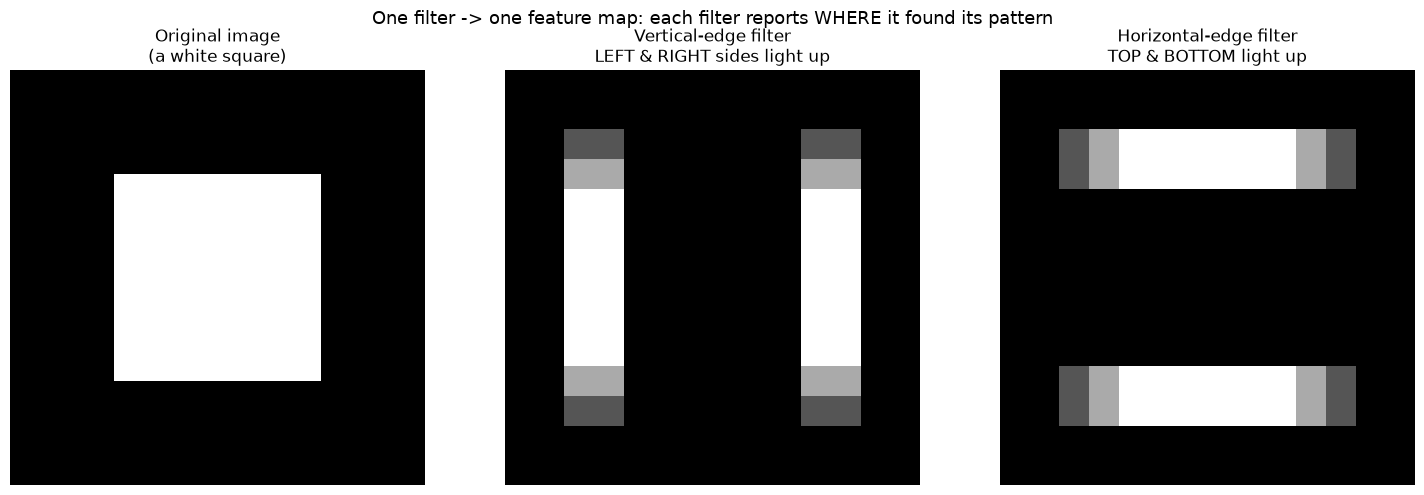

WHAT YOU'RE SEEING:
  - Left: the input image, a plain white square.
  - Middle: the vertical-edge filter fires on the square's LEFT and RIGHT edges.
  - Right: the horizontal-edge filter fires on the TOP and BOTTOM edges.
  - Same image, two filters, two different feature maps.
  - A real CNN LEARNS filters like these automatically during training.


In [2]:
# VISUAL: Convolution in action - one filter makes one feature map
# We slide two hand-made 3x3 filters across a simple image and watch what each detects.

def convolve2d(image, kernel):
    """Slide 'kernel' over 'image' (valid mode) and return the feature map."""
    kh, kw = kernel.shape
    oh, ow = image.shape[0] - kh + 1, image.shape[1] - kw + 1
    out = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            out[i, j] = np.sum(image[i:i+kh, j:j+kw] * kernel)
    return out

# A simple image: a white square on a black background
image = np.zeros((16, 16))
image[4:12, 4:12] = 1.0

# Two filters (kernels) - each detects one kind of edge
vertical_kernel = np.array([[1, 0, -1],
                            [1, 0, -1],
                            [1, 0, -1]])
horizontal_kernel = np.array([[ 1,  1,  1],
                              [ 0,  0,  0],
                              [-1, -1, -1]])

# Slide each filter across the image to produce a feature map
vertical_edges = convolve2d(image, vertical_kernel)
horizontal_edges = convolve2d(image, horizontal_kernel)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original image\n(a white square)', fontsize=12)
axes[1].imshow(np.abs(vertical_edges), cmap='gray')
axes[1].set_title('Vertical-edge filter\nLEFT & RIGHT sides light up', fontsize=12)
axes[2].imshow(np.abs(horizontal_edges), cmap='gray')
axes[2].set_title('Horizontal-edge filter\nTOP & BOTTOM light up', fontsize=12)
for ax in axes:
    ax.axis('off')
plt.suptitle('One filter -> one feature map: each filter reports WHERE it found its pattern',
             fontsize=13)
plt.tight_layout()
plt.show()

print("WHAT YOU'RE SEEING:")
print("  - Left: the input image, a plain white square.")
print("  - Middle: the vertical-edge filter fires on the square's LEFT and RIGHT edges.")
print("  - Right: the horizontal-edge filter fires on the TOP and BOTTOM edges.")
print("  - Same image, two filters, two different feature maps.")
print("  - A real CNN LEARNS filters like these automatically during training.")


### What Patterns Do Filters Learn?

You don't define the filters - the network LEARNS them during training!

```
WHAT CNN FILTERS LEARN (hierarchically):

LAYER 1 (Close to input - simple patterns):
┌─────────────────────────────────────────────────────────────────────┐
│                                                                     │
│   ┌───┐  ┌───┐  ┌───┐  ┌───┐  ┌───┐  ┌───┐                        │
│   │|||│  │───│  │ / │  │ \ │  │░░░│  │▓▓▓│                        │
│   │|||│  │───│  │ / │  │ \ │  │░░░│  │▓▓▓│                        │
│   │|||│  │───│  │ / │  │ \ │  │░░░│  │▓▓▓│                        │
│   └───┘  └───┘  └───┘  └───┘  └───┘  └───┘                        │
│  vertical horiz  diag  diag   light  dark                          │
│   edges  edges  left  right  region region                        │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘

LAYER 2 (Middle - combines simple patterns):
┌─────────────────────────────────────────────────────────────────────┐
│                                                                     │
│   ┌───┐  ┌───┐  ┌───┐  ┌───┐  ┌───┐                               │
│   │ ┌ │  │ ┐ │  │ ○ │  │ □ │  │ ╱╲│                               │
│   │ │ │  │ │ │  │   │  │   │  │╱  ╲│                               │
│   └───┘  └───┘  └───┘  └───┘  └───┘                               │
│  corner corner curve  corner  angle                                │
│   top-L  top-R               shape                                 │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘

LAYER 3+ (Deep - high-level concepts):
┌─────────────────────────────────────────────────────────────────────┐
│                                                                     │
│   For digits: loops (0,8), stems (1,7), curves (2,3,5)            │
│   For faces:  eyes, noses, mouths                                  │
│   For flowers: petals, stems, leaves                               │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘

The network automatically learns this hierarchy from data!
Early layers → simple patterns
Deep layers → complex, task-specific patterns
```

---

### 🎮 Interactive Demo: See Hierarchical Features in Action

The concept of hierarchical features (simple → complex) is easier to understand when you SEE it happening. Let's peek ahead at a real CNN called **VGG16** - a famous network trained on millions of images.

**In the Convolution Explorer app**, click **"▶ Run VGG16 Layer by Layer"** to watch:
- How the **input image** (224×224×3) enters the network
- **Early layers** producing edge-like feature maps
- **Middle layers** combining edges into textures and shapes
- **Deep layers** detecting complex object parts
- **Final prediction** with confidence percentages

Don't worry if VGG16 seems complex right now - we'll build simpler CNNs first. This demo just shows WHERE we're heading: networks that automatically learn this powerful hierarchy!

---

### Conv2D in Keras

```python
layers.Conv2D(
    filters=32,           # Number of different patterns to learn
    kernel_size=(3, 3),   # Size of each filter (3×3 pixels)
    activation='relu',    # Non-linearity (same as Dense!)
    padding='same'        # Keep output size = input size
)
```

**Understanding the parameters:**

```
┌─────────────────────────────────────────────────────────────────────┐
│  PARAMETER        MEANING                    TYPICAL VALUES        │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  filters          How many different          32, 64, 128           │
│                   patterns to detect?         (more in deeper      │
│                   Each creates one             layers)              │
│                   feature map                                       │
│                                                                     │
│  kernel_size      Size of the sliding         (3,3) most common    │
│                   window                       (5,5) for larger    │
│                   3×3 = 9 weights per filter   patterns            │
│                                                                     │
│  activation       Non-linearity               'relu' almost always │
│                   (same as Day 1!)            Allows learning      │
│                                                complex patterns     │
│                                                                     │
│  padding='same'   What happens at edges?      Output size equals   │
│                   'same' adds zeros around    input size           │
│                   'valid' shrinks output                           │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

---

### 🎮 Interactive Demo: Convolution Explorer

**Try it yourself!** Run the Convolution Explorer app to see convolution in action:

```bash
cd convolution_explorer && python main.py
```

**What you can explore:**
- Select different kernels (Edge Detection, Blur, Sharpen, VGG16 filters)
- Enable **Grid Mode** and hover over the image to see the kernel sliding
- **Click** to see the exact mathematical calculation (element-wise multiply and sum)
- Click **"Apply Filter to Full Image"** to see the result on the entire image

This hands-on visualization shows exactly how the 3×3 filter slides across the image and produces the output feature map!

---

## Block 2: MaxPool2D - The Size Reducer

**What it does:** Shrinks the feature maps while keeping the most important information.

**Analogy:** Instead of "Did I find an edge at pixel (5,7)?", we ask "Did I find an edge SOMEWHERE in this 2×2 region?"

### How Max Pooling Works

```
MAX POOLING (2×2, stride 2):

Input Feature Map (4×4):              Output (2×2):

┌───────┬───────┐                     ┌───────┐
│ 1   3 │ 2   4 │                     │       │
│       │       │   Take MAX          │ 6   8 │   max(1,3,5,6)=6, max(2,4,7,8)=8
│ 5   6 │ 7   8 │   from each   →     │       │   max(0,2,4,1)=4, max(3,9,1,2)=9
├───────┼───────┤   2×2 region        │ 4   9 │
│ 0   2 │ 3   9 │                     │       │
│       │       │                     └───────┘
│ 4   1 │ 1   2 │
└───────┴───────┘

   4×4 = 16 values                      2×2 = 4 values
                                        
                    Size reduced by 4×!
```

**Why is this useful?**

```
BENEFITS OF MAX POOLING:

1. REDUCES COMPUTATION
   Before pooling: 28×28 = 784 values per feature map
   After pooling:  14×14 = 196 values per feature map
   → 4× fewer computations in subsequent layers!

2. TRANSLATION INVARIANCE
   A "7" shifted by 1 pixel will produce nearly the same output
   (as long as the shift is within the pooling region)

3. FOCUSES ON STRONGEST SIGNAL
   "Did I strongly detect an edge somewhere here?"
   vs "Did I weakly detect edges at exact positions?"

4. REDUCES OVERFITTING
   Fewer parameters, less chance to memorize training data
```

**In Keras:**
```python
layers.MaxPool2D(pool_size=(2, 2))  # Most common: 2×2
```

---

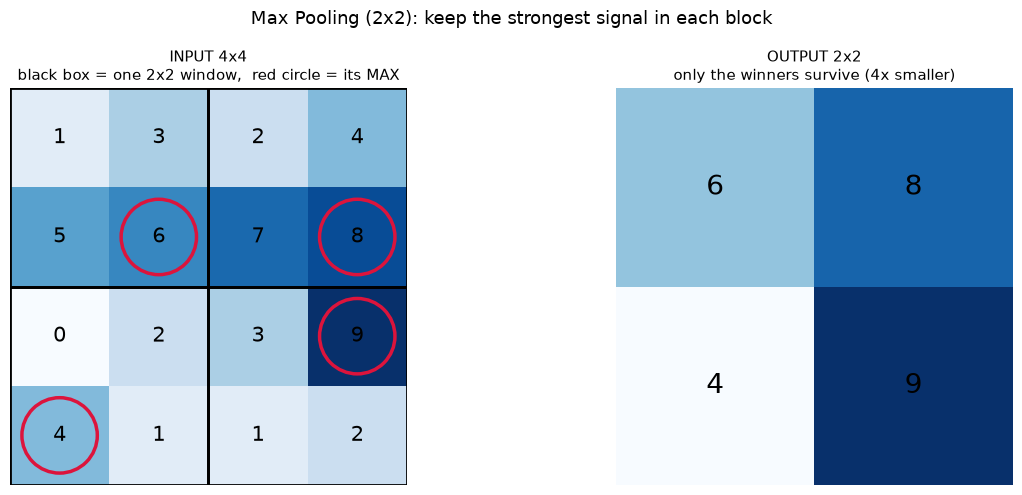

WHAT YOU'RE SEEING:
  - Top-left window [1,3,5,6] -> max is 6.   Top-right [2,4,7,8] -> 8.
  - Bottom-left [0,2,4,1] -> 4.   Bottom-right [3,9,1,2] -> 9.
  - The 4x4 grid (16 numbers) becomes a 2x2 grid (4 numbers) - 4x smaller.
  - We kept the strongest activation in each region and dropped exact positions.


In [3]:
# VISUAL: Max pooling in action - keep the strongest value in each 2x2 block
# Left: the exact 4x4 grid from the slide, each 2x2 window boxed with its MAX circled.
# Right: the shrunken 2x2 result.
import matplotlib.patches as patches

feature_map = np.array([[1, 3, 2, 4],
                        [5, 6, 7, 8],
                        [0, 2, 3, 9],
                        [4, 1, 1, 2]])

def max_pool_2x2(x):
    h, w = x.shape[0] // 2, x.shape[1] // 2
    out = np.zeros((h, w))
    for i in range(h):
        for j in range(w):
            out[i, j] = x[2*i:2*i+2, 2*j:2*j+2].max()
    return out

pooled = max_pool_2x2(feature_map)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: 4x4 input, numbers shown, each 2x2 window boxed, its max circled
ax = axes[0]
ax.imshow(feature_map, cmap='Blues')
for i in range(4):
    for j in range(4):
        ax.text(j, i, int(feature_map[i, j]), ha='center', va='center', fontsize=15)
for bi in range(2):
    for bj in range(2):
        block = feature_map[2*bi:2*bi+2, 2*bj:2*bj+2]
        mi, mj = np.unravel_index(block.argmax(), block.shape)
        ax.add_patch(patches.Rectangle((2*bj-0.5, 2*bi-0.5), 2, 2,
                                        fill=False, edgecolor='black', lw=2))
        ax.add_patch(patches.Circle((2*bj+mj, 2*bi+mi), 0.38,
                                     fill=False, edgecolor='crimson', lw=2.5))
ax.set_title('INPUT 4x4\nblack box = one 2x2 window,  red circle = its MAX', fontsize=11)
ax.axis('off')

# Right: pooled 2x2 result
ax = axes[1]
ax.imshow(pooled, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(pooled[i, j]), ha='center', va='center', fontsize=20)
ax.set_title('OUTPUT 2x2\nonly the winners survive (4x smaller)', fontsize=11)
ax.axis('off')

plt.suptitle('Max Pooling (2x2): keep the strongest signal in each block', fontsize=13)
plt.tight_layout()
plt.show()

print("WHAT YOU'RE SEEING:")
print("  - Top-left window [1,3,5,6] -> max is 6.   Top-right [2,4,7,8] -> 8.")
print("  - Bottom-left [0,2,4,1] -> 4.   Bottom-right [3,9,1,2] -> 9.")
print("  - The 4x4 grid (16 numbers) becomes a 2x2 grid (4 numbers) - 4x smaller.")
print("  - We kept the strongest activation in each region and dropped exact positions.")


### 🎮 Interactive Demo: MaxPooling

**See MaxPooling step-by-step!** In the Convolution Explorer app:

```bash
cd convolution_explorer && python main.py
```

Click **"MaxPooling Demo"** in the CNN Concepts panel to:
- Watch the 2×2 pooling window slide across an 8×8 grid
- See the **MAX value highlighted in green** in each region
- Step through with **Prev/Next** buttons
- Try **2×2 vs 4×4** pool sizes
- **Randomize** the input to see different examples

Notice how the output is smaller (8×8 → 4×4) while keeping the maximum activations!

---

## Block 3: Flatten - The Bridge to Classification

After all Conv2D and MaxPool2D layers, we have 2D feature maps.
But Dense layers (for classification) need a 1D vector.

**Flatten** converts 2D → 1D:

```
FLATTEN:

After Conv+Pool layers:              After Flatten:         To Dense:

Feature Map 1:  ┌─────┐
                │ 7×7 │
                └─────┘   ×64        [3136 values]          ┌───────┐
                  ↓      filters          ↓                 │Dense  │
                                                      →     │128    │ → Output
                7 × 7 × 64               7×7×64=3136        │neurons│
                = 3136 values                               └───────┘

"OK, we've found patterns in the image. Now let's classify!"

After Flatten, we're back to what you know from Day 1:
    Flatten output → Dense(128, relu) → Dense(10, softmax) → Prediction
```

**Why is Flatten OK here but bad at the start?**

```
AT THE START (raw pixels):
    Flattening loses: "These pixels are neighbors in the image"
    This information is crucial for detecting edges!

AT THE END (after Conv layers):
    The Conv layers already extracted spatial patterns
    Feature maps contain: "Edge detected here, curve detected there"
    The spatial work is DONE - now we just need to classify!
```

---

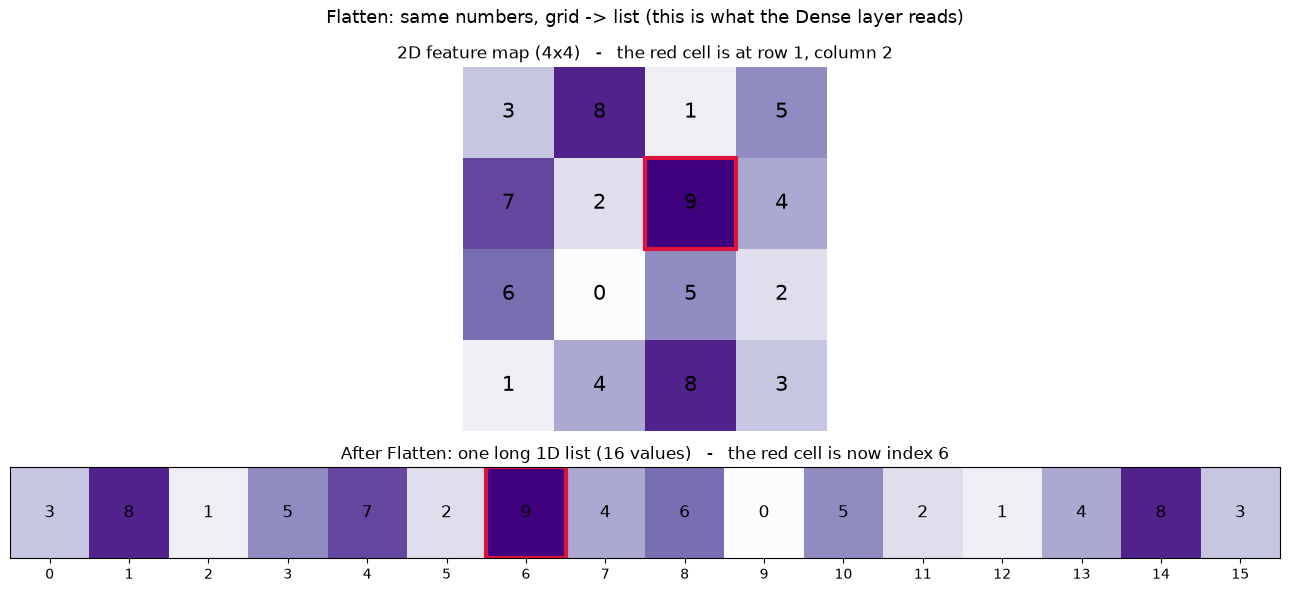

WHAT YOU'RE SEEING:
  - Top: the numbers live in a 2D grid (rows and columns).
  - Bottom: the SAME numbers, unrolled row by row into one straight line.
  - The cell at row 1, column 2 is now at index 6  (= 1 x 4 + 2).
  - The values are untouched - only their arrangement changed.
  - Grid position is gone, which is fine: the Conv layers already used it.


In [4]:
# VISUAL: Flatten in action - a 2D grid becomes a 1D list
# The values are unchanged - they're just re-arranged from a grid into one long row.
import matplotlib.patches as patches

feature_map = np.array([[3, 8, 1, 5],
                        [7, 2, 9, 4],
                        [6, 0, 5, 2],
                        [1, 4, 8, 3]])

flat = feature_map.flatten()   # unroll row by row

fig, axes = plt.subplots(2, 1, figsize=(13, 6),
                         gridspec_kw={'height_ratios': [4, 1]})

# Top: the 2D grid, with the cell at row 1, col 2 highlighted
ax = axes[0]
ax.imshow(feature_map, cmap='Purples')
for i in range(4):
    for j in range(4):
        ax.text(j, i, int(feature_map[i, j]), ha='center', va='center', fontsize=15)
ax.add_patch(patches.Rectangle((2-0.5, 1-0.5), 1, 1, fill=False, edgecolor='crimson', lw=3))
ax.set_title('2D feature map (4x4)   -   the red cell is at row 1, column 2', fontsize=12)
ax.axis('off')

# Bottom: the flattened 1D vector, same red cell now at index 6
ax = axes[1]
ax.imshow(flat.reshape(1, -1), cmap='Purples', aspect='auto')
for k in range(len(flat)):
    ax.text(k, 0, int(flat[k]), ha='center', va='center', fontsize=12)
ax.add_patch(patches.Rectangle((6-0.5, -0.5), 1, 1, fill=False, edgecolor='crimson', lw=3))
ax.set_title('After Flatten: one long 1D list (16 values)   -   the red cell is now index 6',
             fontsize=12)
ax.set_yticks([])
ax.set_xticks(range(16))

plt.suptitle('Flatten: same numbers, grid -> list (this is what the Dense layer reads)',
             fontsize=13)
plt.tight_layout()
plt.show()

print("WHAT YOU'RE SEEING:")
print("  - Top: the numbers live in a 2D grid (rows and columns).")
print("  - Bottom: the SAME numbers, unrolled row by row into one straight line.")
print("  - The cell at row 1, column 2 is now at index 6  (= 1 x 4 + 2).")
print("  - The values are untouched - only their arrangement changed.")
print("  - Grid position is gone, which is fine: the Conv layers already used it.")


### 🎮 Interactive Demo: Flatten Visualization

**Understand why Flatten loses spatial information!** In the Convolution Explorer app:

```bash
cd convolution_explorer && python main.py
```

Click **"Flatten Visualization"** in the CNN Concepts panel to see:
- 2D feature maps (7×7×512) visualized as a grid
- The arrow showing the **FLATTEN** operation
- The resulting 1D vector (25,088 values!)
- **The key problem:** Position (row=2, col=3) becomes just "index 17"

This visualization shows why we do convolutions FIRST (to extract spatial patterns) and THEN flatten (to classify).

---

## Complete CNN Architecture

Let's put it all together:

```
TYPICAL CNN FOR IMAGE CLASSIFICATION:

                         ┌──────────────────────────────────────────────┐
INPUT                    │             FEATURE EXTRACTION               │
                         │                                              │
Image (28×28×1)          │  BLOCK 1              BLOCK 2                │
     │                   │                                              │
     ▼                   │  Conv2D(32, 3×3)      Conv2D(64, 3×3)       │
┌─────────┐              │       │                    │                │
│ 28 × 28 │              │       ▼                    ▼                │
│    ×    │   ──────►    │  MaxPool2D(2×2)       MaxPool2D(2×2)        │
│    1    │              │       │                    │                │
└─────────┘              │       ▼                    ▼                │
                         │  (14×14×32)           (7×7×64)              │
                         │                                              │
                         └──────────────────────────────────────────────┘
                                              │
                                              ▼
                         ┌──────────────────────────────────────────────┐
                         │             CLASSIFICATION                   │
                         │                                              │
                         │  Flatten         Dense(128)      Dense(10)  │
                         │     │                │              │       │
                         │     ▼                ▼              ▼       │
                         │  [3136]    →     [128]     →    [10]       │
                         │                  (ReLU)       (Softmax)    │
                         │                                              │
                         └──────────────────────────────────────────────┘
                                              │
                                              ▼
                                        PREDICTION
                                     "This is a 7"

SIZE PROGRESSION:
    Input:     28 × 28 × 1  = 784 values
    After B1:  14 × 14 × 32 = 6,272 values (more channels, smaller spatial)
    After B2:   7 ×  7 × 64 = 3,136 values (even more channels, even smaller)
    Flatten:   3,136 values
    Dense:     128 values
    Output:    10 values (one per digit)
```

---

---

# Part 3: Hands-On - MNIST Digit Classification

**Theory time is over - let's build!** 🚀

You now know the three CNN building blocks:
- **Conv2D** - slides filters to detect patterns
- **MaxPool2D** - shrinks size while keeping important info  
- **Flatten** - bridges 2D features to Dense classification

Time to put them together. We'll use the classic **MNIST dataset** - handwritten digits 0-9. This is perfect for learning because:
- Images are small (28×28) → fast training
- Task is intuitive (recognize handwritten numbers)
- We can compare Dense vs CNN and SEE the difference

```
MNIST DATASET:

┌─────────────────────────────────────────────────────────────────────┐
│  • 60,000 training images                                          │
│  • 10,000 test images                                              │
│  • Each image: 28×28 pixels, grayscale (1 channel)                │
│  • 10 classes: digits 0, 1, 2, 3, 4, 5, 6, 7, 8, 9                │
│                                                                     │
│  Sample images:                                                     │
│  ┌───┐ ┌───┐ ┌───┐ ┌───┐ ┌───┐ ┌───┐ ┌───┐ ┌───┐ ┌───┐ ┌───┐    │
│  │ 0 │ │ 1 │ │ 2 │ │ 3 │ │ 4 │ │ 5 │ │ 6 │ │ 7 │ │ 8 │ │ 9 │    │
│  └───┘ └───┘ └───┘ └───┘ └───┘ └───┘ └───┘ └───┘ └───┘ └───┘    │
│                                                                     │
│  WHY MNIST?                                                         │
│  • Classic benchmark - every ML practitioner has used it           │
│  • Small enough to train quickly (good for learning!)              │
│  • Complex enough to show CNN advantage over Dense                 │
└─────────────────────────────────────────────────────────────────────┘
```

---

In [5]:
# Step 1: Load the MNIST dataset
# Keras has it built-in - no download needed!

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("MNIST Dataset Loaded!")
print("=" * 50)
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape:     {X_test.shape}")
print(f"\nWhat does this mean?")
print(f"  X_train: {X_train.shape[0]} images, each {X_train.shape[1]}×{X_train.shape[2]} pixels")
print(f"  X_test:  {X_test.shape[0]} images for final evaluation")
print(f"\nLabels: {np.unique(y_train)} (digits 0-9)")
print(f"Pixel value range: {X_train.min()} to {X_train.max()}")

MNIST Dataset Loaded!
Training set shape: (60000, 28, 28)
Test set shape:     (10000, 28, 28)

What does this mean?
  X_train: 60000 images, each 28×28 pixels
  X_test:  10000 images for final evaluation

Labels: [0 1 2 3 4 5 6 7 8 9] (digits 0-9)
Pixel value range: 0 to 255


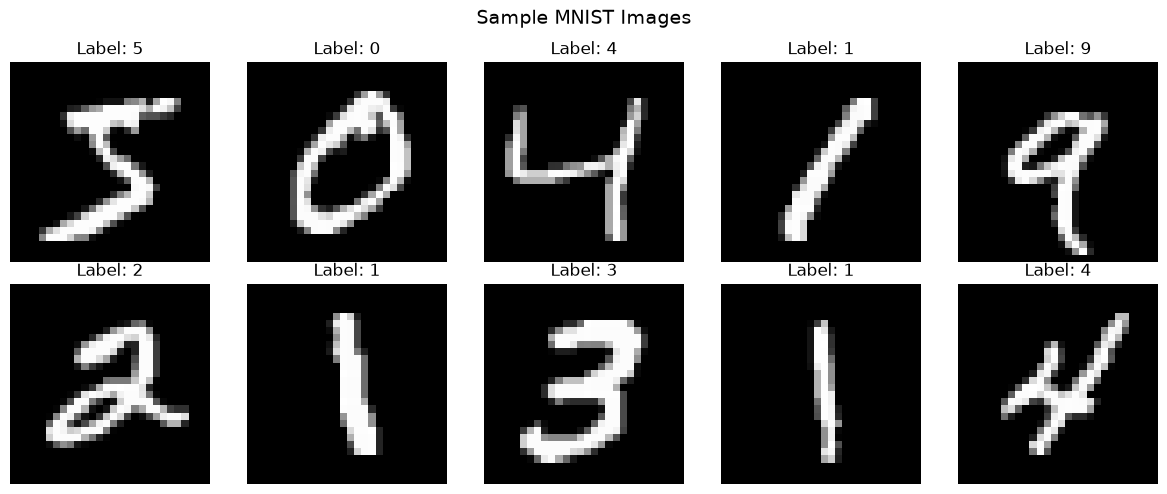

Notice the variation in handwriting styles!
This is what makes the task interesting.


In [6]:
# Step 2: Visualize some samples
# Always look at your data before building models!

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}', fontsize=12)
    ax.axis('off')

plt.suptitle('Sample MNIST Images', fontsize=14)
plt.tight_layout()
plt.show()

print("Notice the variation in handwriting styles!")
print("This is what makes the task interesting.")

In [7]:
# Step 3: Preprocess the data
# Two important transformations!

# TRANSFORMATION 1: Normalize pixel values from 0-255 to 0-1
# Why? Neural networks work better with small values (gradient stability)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# TRANSFORMATION 2: Reshape for CNN
# Original shape: (60000, 28, 28) - missing channel dimension!
# CNN expects:    (60000, 28, 28, 1) - with channel dimension
#                                  ↑
#                               1 channel for grayscale
#                               (RGB would be 3 channels)

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("After preprocessing:")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_test shape:  {X_test.shape}")
print(f"  Pixel range:   {X_train.min():.1f} to {X_train.max():.1f}")
print(f"\nThe '1' at the end means 1 color channel (grayscale).")
print(f"For color images, this would be 3 (RGB).")

After preprocessing:
  X_train shape: (60000, 28, 28, 1)
  X_test shape:  (10000, 28, 28, 1)
  Pixel range:   0.0 to 1.0

The '1' at the end means 1 color channel (grayscale).
For color images, this would be 3 (RGB).


## Experiment: Dense Network vs CNN

We've made big claims about CNNs being better than Dense networks for images. Let's **prove it!**

Here's our experiment:
1. Build a **Dense Network** (like Day 1) - flatten the image and use Dense layers
2. Build a **CNN** - use Conv2D and MaxPool2D
3. Train both on the SAME data for the SAME number of epochs
4. Compare accuracy

This is real science: same data, same training, different architectures. May the best network win!

---

In [8]:
# MODEL 1: Dense Network (Baseline)
# This is what you'd build without knowing about CNNs

model_dense = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # Flatten: 28×28×1 = 784 values
    layers.Flatten(),

    # Dense layers (same pattern as Day 1!)
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    # Output: 10 neurons for 10 digits, softmax for probabilities
    layers.Dense(10, activation='softmax')
])

model_dense.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # For integer labels (0-9)
    metrics=['accuracy']
)

print("Dense Network Architecture:")
print("=" * 60)
model_dense.summary()
print(f"\nTotal parameters: {model_dense.count_params():,}")

Dense Network Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 109,386


In [9]:
# Train the Dense network

print("Training Dense Network...")
print("(This shows that Dense networks CAN work on images)")
print()

history_dense = model_dense.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# Evaluate on test set
loss_dense, acc_dense = model_dense.evaluate(X_test, y_test, verbose=0)
print(f"\nDense Network Test Accuracy: {acc_dense:.2%}")
print(f"That's {acc_dense * 10000:.0f} correct out of 10,000!")

Training Dense Network...
(This shows that Dense networks CAN work on images)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8984 - loss: 0.3590 - val_accuracy: 0.9617 - val_loss: 0.1401
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9551 - loss: 0.1502 - val_accuracy: 0.9687 - val_loss: 0.1055
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9687 - loss: 0.1062 - val_accuracy: 0.9732 - val_loss: 0.0913
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9763 - loss: 0.0803 - val_accuracy: 0.9752 - val_loss: 0.0853
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9818 - loss: 0.0625 - val_accuracy: 0.9740 - val_loss: 0.0840

Dense Network Test Accuracy: 97.27%
That's 9727 correct out of 10,000!


In [10]:
# MODEL 2: Convolutional Neural Network (CNN)
# Now let's use what we learned!

model_cnn = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # BLOCK 1: First convolutional block
    # 32 filters of size 3×3 - learn 32 different patterns
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    # Reduce size by half: 28×28 → 14×14
    layers.MaxPool2D((2, 2)),

    # BLOCK 2: Second convolutional block
    # 64 filters - learn more complex patterns
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    # Reduce again: 14×14 → 7×7
    layers.MaxPool2D((2, 2)),

    # CLASSIFICATION HEAD
    # Flatten: 7×7×64 = 3136 values
    layers.Flatten(),
    # Dense layer for classification
    layers.Dense(128, activation='relu'),
    # Output: 10 digits
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN Architecture:")
print("=" * 60)
model_cnn.summary()
print(f"\nTotal parameters: {model_cnn.count_params():,}")

CNN Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 421,642


In [11]:
# Train the CNN

print("Training CNN...")
print("(Watch the accuracy - should be higher than Dense!)")
print()

history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# Evaluate on test set
loss_cnn, acc_cnn = model_cnn.evaluate(X_test, y_test, verbose=0)
print(f"\nCNN Test Accuracy: {acc_cnn:.2%}")
print(f"That's {acc_cnn * 10000:.0f} correct out of 10,000!")

Training CNN...
(Watch the accuracy - should be higher than Dense!)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.9403 - loss: 0.2025 - val_accuracy: 0.9828 - val_loss: 0.0633
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - accuracy: 0.9827 - loss: 0.0557 - val_accuracy: 0.9873 - val_loss: 0.0471
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 29s 69ms/step - accuracy: 0.9883 - loss: 0.0367 - val_accuracy: 0.9877 - val_loss: 0.0436
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - accuracy: 0.9914 - loss: 0.0274 - val_accuracy: 0.9888 - val_loss: 0.0409
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 64ms/step - accuracy: 0.9941 - loss: 0.0195 - val_accuracy: 0.9890 - val_loss: 0.0439

CNN Test Accuracy: 98.74%
That's 9874 correct out of 10,000!


In [12]:
# COMPARISON: Dense vs CNN

print("\n" + "=" * 60)
print("           MODEL COMPARISON")
print("=" * 60)
print(f"\n{'Metric':<25} {'Dense':>15} {'CNN':>15}")
print("-" * 60)
print(f"{'Test Accuracy':<25} {acc_dense:>14.2%} {acc_cnn:>14.2%}")
print(f"{'Correct (out of 10,000)':<25} {int(acc_dense*10000):>15,} {int(acc_cnn*10000):>15,}")
print(f"{'Errors':<25} {int((1-acc_dense)*10000):>15,} {int((1-acc_cnn)*10000):>15,}")
print(f"{'Parameters':<25} {model_dense.count_params():>15,} {model_cnn.count_params():>15,}")
print("=" * 60)

improvement = (acc_cnn - acc_dense) * 100
error_reduction = (1 - acc_cnn) / (1 - acc_dense)
print(f"\nCNN improved accuracy by {improvement:.2f} percentage points")
print(f"CNN reduced errors by {(1-error_reduction)*100:.1f}%!")


           MODEL COMPARISON

Metric                              Dense             CNN
------------------------------------------------------------
Test Accuracy                     97.27%         98.74%
Correct (out of 10,000)             9,726           9,873
Errors                                273             126
Parameters                        109,386         421,642

CNN improved accuracy by 1.47 percentage points
CNN reduced errors by 53.8%!


### 🎮 Interactive Demo: CNN vs Dense Parameters

**See why CNNs scale better!** In the Convolution Explorer app:

```bash
cd convolution_explorer && python main.py
```

Click **"CNN vs Dense Parameters"** in the CNN Concepts panel to:
- Compare parameter counts side-by-side
- **Change the image size** (28×28, 64×64, 128×128, 224×224, 512×512)
- Watch Dense network parameters **explode** while CNN stays manageable
- See the efficiency ratio (CNNs can be 50-100× more efficient!)

For a 224×224 image, Dense needs ~19 million parameters for just the first layer, while CNN needs only ~900!

---

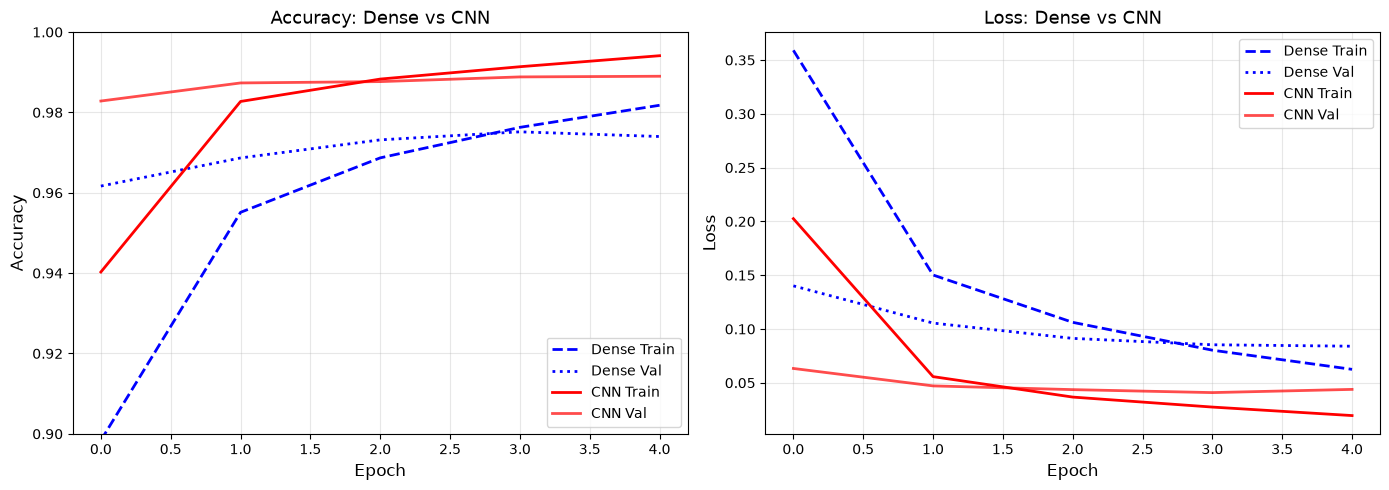

KEY OBSERVATIONS:
  • CNN reaches higher accuracy faster
  • CNN has lower loss (more confident predictions)
  • Both converge well (no severe overfitting in 5 epochs)


In [13]:
# Visualize training curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(history_dense.history['accuracy'], 'b--', label='Dense Train', linewidth=2)
axes[0].plot(history_dense.history['val_accuracy'], 'b:', label='Dense Val', linewidth=2)
axes[0].plot(history_cnn.history['accuracy'], 'r-', label='CNN Train', linewidth=2)
axes[0].plot(history_cnn.history['val_accuracy'], 'r-', label='CNN Val', linewidth=2, alpha=0.7)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy: Dense vs CNN', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.9, 1.0])

# Loss comparison
axes[1].plot(history_dense.history['loss'], 'b--', label='Dense Train', linewidth=2)
axes[1].plot(history_dense.history['val_loss'], 'b:', label='Dense Val', linewidth=2)
axes[1].plot(history_cnn.history['loss'], 'r-', label='CNN Train', linewidth=2)
axes[1].plot(history_cnn.history['val_loss'], 'r-', label='CNN Val', linewidth=2, alpha=0.7)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Loss: Dense vs CNN', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("KEY OBSERVATIONS:")
print("  • CNN reaches higher accuracy faster")
print("  • CNN has lower loss (more confident predictions)")
print("  • Both converge well (no severe overfitting in 5 epochs)")

---

# Part 4: Multi-Class Classification Deep Dive

You just saw CNNs outperform Dense networks on MNIST. But we glossed over something important: **MNIST has 10 classes**, not 2!

On Day 1, sigmoid gave you **binary classification** - one probability for a yes/no answer. MNIST has **10 classes** (digits 0-9). This is called **multi-class classification**, and it requires some changes to our output layer and loss function.

Let's understand the key differences:

```
COMPARISON: Binary vs Multi-Class

┌─────────────────────────┬────────────────────────────────────────────┐
│     BINARY (Day 1)      │        MULTI-CLASS (Today)                 │
├─────────────────────────┼────────────────────────────────────────────┤
│                         │                                            │
│  Classes: 2             │  Classes: 10 (or any N > 2)               │
│  (inner vs outer)       │  (digits 0-9)                             │
│                         │                                            │
│  Output layer:          │  Output layer:                             │
│  Dense(1, sigmoid)      │  Dense(10, softmax)                        │
│       ↓                 │       ↓                                    │
│  One number 0-1         │  10 numbers that sum to 1                  │
│  (probability of +)     │  (probability of each class)              │
│                         │                                            │
│  Loss function:         │  Loss function:                            │
│  binary_crossentropy    │  categorical_crossentropy                  │
│                         │  or sparse_categorical_crossentropy       │
│                         │                                            │
└─────────────────────────┴────────────────────────────────────────────┘
```

---

## Softmax: Turning Scores into Probabilities

Remember **sigmoid** from Day 1? It squishes one number to 0-1.

**Softmax** does the same thing for MULTIPLE numbers, ensuring they all sum to 1:

```
HOW SOFTMAX WORKS:

Raw scores from last Dense layer (before softmax):
    [2.1,  0.5,  8.2,  1.1,  0.3,  0.1,  0.2,  0.4,  0.6,  0.1]
      0     1     2     3     4     5     6     7     8     9
                  ↑
            Highest score for digit "2"

After softmax (probabilities):
    [0.02, 0.00, 0.93, 0.01, 0.00, 0.00, 0.00, 0.00, 0.01, 0.00]
      0     1     2     3     4     5     6     7     8     9
                  ↑
            93% confident this is a "2"!

Properties of softmax output:
    • All values between 0 and 1  ✓
    • All values sum to exactly 1  ✓ (probability distribution!)
    • Highest input → highest probability
    • Differences are exaggerated (confident predictions)
```

**Formula:**
```
softmax(z_i) = exp(z_i) / sum(exp(z_j) for all j)

"My score, divided by everyone's scores (all exponentiated)"
```

---

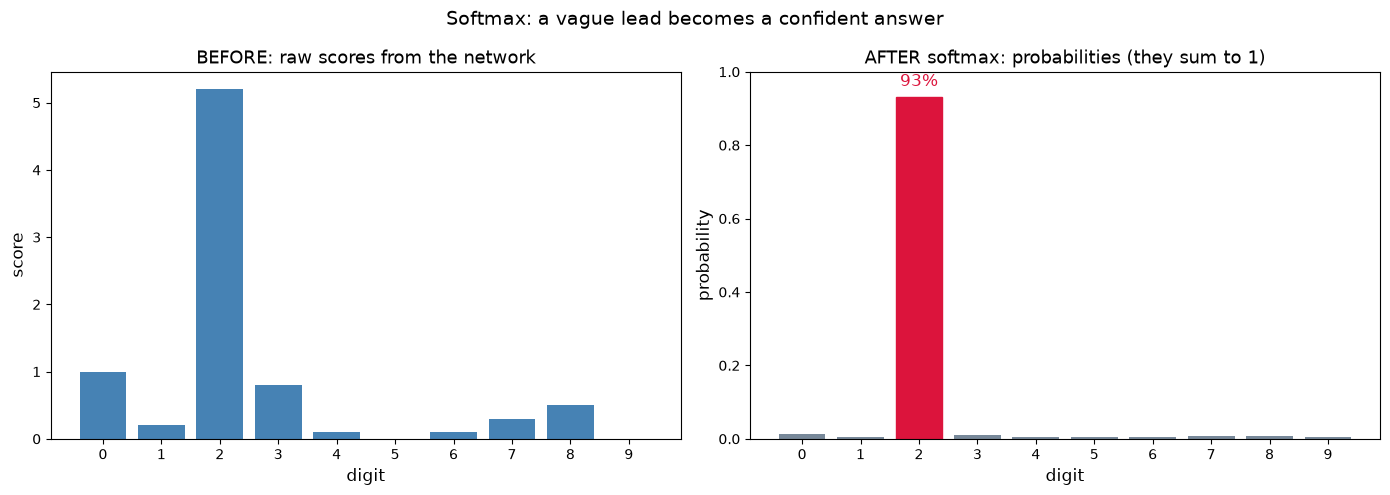

Raw scores sum to:    8.20   (not a probability)
Probabilities sum to: 1.00   (a real probability distribution)
Winner: digit 2 with 93% confidence


In [14]:
# VISUAL: Softmax - turning raw scores into probabilities
# Ten raw scores come out of the last Dense layer (one per digit 0-9).
# Softmax squashes them into probabilities that sum to 1.

scores = np.array([1.0, 0.2, 5.2, 0.8, 0.1, 0.0, 0.1, 0.3, 0.5, 0.0])
digits = np.arange(10)

# softmax: exponentiate every score, then divide by the total
probs = np.exp(scores) / np.sum(np.exp(scores))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(digits, scores, color='steelblue')
axes[0].set_title('BEFORE: raw scores from the network', fontsize=13)
axes[0].set_xlabel('digit', fontsize=12)
axes[0].set_ylabel('score', fontsize=12)
axes[0].set_xticks(digits)

bars = axes[1].bar(digits, probs, color='lightslategray')
bars[int(np.argmax(probs))].set_color('crimson')      # highlight the winner
axes[1].set_title('AFTER softmax: probabilities (they sum to 1)', fontsize=13)
axes[1].set_xlabel('digit', fontsize=12)
axes[1].set_ylabel('probability', fontsize=12)
axes[1].set_xticks(digits)
axes[1].set_ylim(0, 1)
axes[1].text(int(np.argmax(probs)), probs.max() + 0.03,
             f'{probs.max():.0%}', ha='center', fontsize=12, color='crimson')

plt.suptitle('Softmax: a vague lead becomes a confident answer', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Raw scores sum to:    {scores.sum():.2f}   (not a probability)")
print(f"Probabilities sum to: {probs.sum():.2f}   (a real probability distribution)")
print(f"Winner: digit {int(np.argmax(probs))} with {probs.max():.0%} confidence")


## Label Encoding: Integer vs One-Hot

There are two ways to represent multi-class labels:

```
OPTION 1: Integer Labels (what MNIST uses)
─────────────────────────────────────────────

y = [5, 0, 4, 1, 9, 2, ...]    ← Just the digit itself

Use with: loss='sparse_categorical_crossentropy'
          ("sparse" because labels are compact integers)


OPTION 2: One-Hot Encoding
─────────────────────────────────────────────

y = [[0,0,0,0,0,1,0,0,0,0],    ← "5" (1 at index 5)
     [1,0,0,0,0,0,0,0,0,0],    ← "0" (1 at index 0)
     [0,0,0,0,1,0,0,0,0,0],    ← "4" (1 at index 4)
     ...]

Convert with: y_onehot = keras.utils.to_categorical(y, num_classes=10)
Use with: loss='categorical_crossentropy'


WHICH TO USE?
─────────────────────────────────────────────

• Integer labels + sparse_categorical_crossentropy
  → Simpler, uses less memory
  → MNIST comes this way!

• One-hot + categorical_crossentropy
  → Required by some data loaders (like image_dataset_from_directory)
  → Mathematically identical results
```

---

## Colab Setup - Load the Flowers (run once)

**Before the flower cells:** upload `Data.zip` to your Google Drive (My Drive), then
run the cell below. It mounts Drive and unzips the flowers to `/content/Data`.

If a Colab runtime resets mid-lecture, just run this cell again - no re-upload.
(Running locally instead? Skip this cell and point `DATA_DIR` at your folder in the config cell.)

In [15]:
# Colab setup: put the flowers at /content/Data (run once, Colab only)
# Mounts Google Drive and unzips Data.zip. Safe to re-run; skips if already done.
import os, subprocess

if os.path.isdir("/content/Data/train"):
    print("Flowers already at /content/Data - nothing to do.")
else:
    ZIP_PATH = "/content/drive/MyDrive/Data.zip"   # <- where you put Data.zip in Drive
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.exists(ZIP_PATH):
            print(f"Unzipping {ZIP_PATH} ...")
            subprocess.run(["unzip", "-q", ZIP_PATH, "-d", "/content"], check=True)
            print("Done unzipping.")
        else:
            print(f"Data.zip not found at {ZIP_PATH}.")
            print("Upload Data.zip to your Drive (My Drive), or edit ZIP_PATH above.")
    except ModuleNotFoundError:
        print("Not on Colab - running locally? Point DATA_DIR at your flower folder in the config cell.")

# Quick check
print("\nContents of /content/Data:")
subprocess.run(["ls", "/content/Data"]) if os.path.isdir("/content/Data") else print("  (not present yet)")


Not on Colab - running locally? Point DATA_DIR at your flower folder in the config cell.

Contents of /content/Data:
  (not present yet)


---

# Part 5: Loading Images from Folders

So far, we've had it easy: MNIST came **pre-packaged** with `keras.datasets.mnist.load_data()`. The data was already:
- Loaded into numpy arrays
- Normalized  
- Split into train/test

But what about **your own images**? What if you want to classify flowers, medical scans, or product photos?

Real-world image datasets are usually organized in **folders**, where each folder represents a class:

```
TYPICAL FOLDER STRUCTURE:

dataset/
├── train/
│   ├── cat/
│   │   ├── cat_001.jpg
│   │   ├── cat_002.jpg
│   │   └── ... (hundreds more)
│   ├── dog/
│   │   ├── dog_001.jpg
│   │   └── ...
│   └── bird/
│       └── ...
│
└── validation/
    ├── cat/
    ├── dog/
    └── bird/

The folder NAME is the label!
    Images in 'cat/' folder → labeled as 'cat'
    Images in 'dog/' folder → labeled as 'dog'
```

Good news: Keras has a built-in function to load this automatically! You won't need to write loops or handle file I/O yourself.

---

## Using `image_dataset_from_directory`

```python
from tensorflow.keras.utils import image_dataset_from_directory

# Load training data
train_dataset = image_dataset_from_directory(
    'path/to/train',           # Path to the folder
    image_size=(128, 128),     # Resize all images to this size
    batch_size=32,             # How many images per batch
    label_mode='categorical'   # One-hot encode the labels
)

# Load validation data
val_dataset = image_dataset_from_directory(
    'path/to/validation',
    image_size=(128, 128),
    batch_size=32,
    label_mode='categorical'
)

# See what classes were found
print(train_dataset.class_names)  # ['bird', 'cat', 'dog']
```

**What this function does for you:**

```
┌─────────────────────────────────────────────────────────────────────┐
│  AUTOMATIC HANDLING                                                 │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  ✓ Discovers class names from folder names                         │
│  ✓ Loads images from disk (JPEG, PNG, etc.)                        │
│  ✓ Resizes images to specified size                                │
│  ✓ Converts to tensors (numbers)                                   │
│  ✓ Creates labels automatically                                    │
│  ✓ Batches data efficiently                                        │
│  ✓ Shuffles training data                                          │
│                                                                     │
│  YOU get: Ready-to-use dataset for model.fit()!                    │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

---

## Key Parameters

```
┌─────────────────────────────────────────────────────────────────────┐
│  PARAMETER          WHAT IT DOES              COMMON VALUES        │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  directory          Path to folder with       'data/train'         │
│                     class subfolders                               │
│                                                                     │
│  image_size         Resize all images to      (128, 128)           │
│                     (height, width)           (224, 224) for       │
│                                               transfer learning    │
│                                                                     │
│  batch_size         Images per batch          32, 64               │
│                                               (smaller if GPU     │
│                                               runs out of memory) │
│                                                                     │
│  label_mode         How to encode labels      'categorical' = one-hot│
│                                               'int' = integers     │
│                                                                     │
│  color_mode         Image channels            'rgb' (default)      │
│                                               'grayscale'          │
│                                                                     │
│  shuffle            Randomize order?          True for training    │
│                                               False for validation │
│                                                                     │
│  seed               Random seed               42 (reproducibility) │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

---

## Now Let's Actually Load Them (Live)

The two cells above showed the *reference*. Now we run it for real on the flower dataset.

**Setup (Colab):** run the **Colab setup** cell above once (it unzips `Data.zip` from your Drive to `/content/Data`). Then run the three cells below. (Running locally? Just edit `DATA_DIR`.)

In [16]:
# Flower dataset config  (Parts 5-6)
# 1) Upload the 'Data' folder (with train/ and val/ inside) to Colab.
# 2) Make sure DATA_DIR below points at it.
import os
from tensorflow.keras.utils import image_dataset_from_directory

DATA_DIR = "/content/Data"   # <- the folder you uploaded (contains train/ and val/)
IMG_SIZE = (128, 128)        # every image is resized to this
BATCH_SIZE = 32

FLOWERS_READY = os.path.isdir(os.path.join(DATA_DIR, "train"))
if FLOWERS_READY:
    print(f"Found flower data at {DATA_DIR}")
else:
    print(f"Flower data NOT found at {DATA_DIR}")
    print("Upload the 'Data' folder (train/ and val/) to Colab, or edit DATA_DIR above.")
    print("The flower cells below will wait until the data is there.")


Flower data NOT found at /content/Data
Upload the 'Data' folder (train/ and val/) to Colab, or edit DATA_DIR above.
The flower cells below will wait until the data is there.


In [17]:
# Load the flowers straight from folders - one folder per class, no loops!
if FLOWERS_READY:
    train_ds = image_dataset_from_directory(
        os.path.join(DATA_DIR, "train"),
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="int",     # integer labels -> sparse_categorical_crossentropy
        shuffle=True,
        seed=42,
    )
    val_ds = image_dataset_from_directory(
        os.path.join(DATA_DIR, "val"),
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="int",
        shuffle=False,
    )
    class_names = train_ds.class_names
    print(f"\nFound {len(class_names)} classes:")
    print(class_names)
    print(f"\nTraining batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
    print(f"Validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
else:
    print("Set DATA_DIR and upload the flowers first (see the config cell).")


Set DATA_DIR and upload the flowers first (see the config cell).


In [18]:
# Look at the data first - one real photo of each of the 14 flowers
if FLOWERS_READY:
    one_per_class = {}
    for imgs, labs in train_ds.take(40):        # scan a few batches
        for img, lab in zip(imgs, labs):
            c = int(lab)
            if c not in one_per_class:
                one_per_class[c] = img.numpy().astype("uint8")
        if len(one_per_class) == len(class_names):
            break

    plt.figure(figsize=(15, 7))
    for c in range(len(class_names)):
        ax = plt.subplot(3, 5, c + 1)
        ax.imshow(one_per_class[c])
        ax.set_title(class_names[c], fontsize=11)
        ax.axis("off")
    plt.suptitle("The 14 flower classes - real photos, loaded straight from folders",
                 fontsize=14)
    plt.tight_layout()
    plt.show()
    print("One function - image_dataset_from_directory - turned folders of JPEGs into this.")
else:
    print("Set DATA_DIR and upload the flowers first (see the config cell).")


Set DATA_DIR and upload the flowers first (see the config cell).


---

# Part 6: Data Augmentation

Now you know how to load images from folders. But there's a common problem: **you often don't have enough images!**

MNIST has 60,000 training images - that's a lot. But your flower dataset might have only 100 images per class. Your medical imaging project might have even fewer.

CNNs are hungry for data. With too little, they **overfit** - memorizing the training images instead of learning general patterns.

## The Problem: Limited Training Data

```
COMMON SCENARIO:

You have:     5,000 training images
You need:     Much more to train a good CNN!

Collecting more images is:
    • Expensive (need to take/find photos)
    • Time-consuming (need to label each one)
    • Sometimes impossible (rare flowers, medical images)

SOLUTION: Create MORE training data from what you have!
```

## The Idea: Realistic Variations

```
DATA AUGMENTATION:

Original image:        Augmented versions (ALL are the same flower!):

    ┌─────────┐        ┌─────────┐  ┌─────────┐  ┌─────────┐
    │         │        │         │  │         │  │         │
    │   🌸    │   →    │   🌸    │  │    🌸   │  │  🌸     │
    │         │        │  (flip) │  │ (rotate)│  │ (zoom)  │
    └─────────┘        └─────────┘  └─────────┘  └─────────┘

Key insight: A flower is still a flower if you:
    • Flip it horizontally (mirror)
    • Rotate it slightly
    • Zoom in or out
    • Shift it left/right/up/down
    • Change brightness slightly

The model should learn to recognize the flower regardless of these variations!
```

---

## Why Augmentation Helps

```
WITHOUT AUGMENTATION:
─────────────────────────────

Model sees: 100 images of Rose
Model learns: "Rose looks EXACTLY like these 100 examples"

Test time: Slightly different Rose → Model confused!
Result: OVERFITTING (memorized training data)


WITH AUGMENTATION:
─────────────────────────────

Model sees: 100 original + variations = effectively 1000+ images
Model learns: "Rose can look like this, or flipped, or rotated..."

Test time: Slightly different Rose → Model handles it!
Result: GENERALIZATION (learned the concept "Rose")
```

---

## Data Augmentation in Keras

The modern approach: Add augmentation layers to your model!

```python
# Define augmentation as layers
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),      # Mirror left-right
    layers.RandomRotation(0.1),           # Rotate ±10%
    layers.RandomZoom(0.1),               # Zoom ±10%
    layers.RandomTranslation(0.1, 0.1),   # Shift ±10%
])

# Add to your model
model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),
    
    data_augmentation,         # ← Augmentation first!
    layers.Rescaling(1./255),  # ← Then normalize
    
    # Then your CNN layers...
    layers.Conv2D(32, 3, activation='relu'),
    # ...
])
```

**Important:** Augmentation layers are only active during training!
During prediction/evaluation, they do nothing.

---

## Common Augmentation Techniques

```
┌─────────────────────────────────────────────────────────────────────┐
│  TECHNIQUE            WHAT IT DOES           WHEN TO USE           │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  RandomFlip           Mirror horizontally    Most images           │
│  ('horizontal')       or vertically          (NOT text/numbers!)   │
│                                                                     │
│  RandomRotation       Rotate by degrees      Objects that can      │
│  (0.1 = ±36°)         (0.1 = 10% of 360°)   appear rotated        │
│                                                                     │
│  RandomZoom           Zoom in/out            When scale varies     │
│  (0.1 = ±10%)                               (near/far objects)    │
│                                                                     │
│  RandomTranslation    Shift position         When position varies  │
│  (0.1, 0.1)           (width, height %)     (not always centered) │
│                                                                     │
│  RandomBrightness     Lighter/darker         Different lighting    │
│  (0.2 = ±20%)                               conditions            │
│                                                                     │
│  RandomContrast       More/less contrast     Different cameras     │
│  (0.2 = ±20%)                               or settings           │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘

CAUTION: Don't use augmentations that destroy the label!
    • Don't flip digits (6 becomes 9!)
    • Don't rotate text too much
    • Don't zoom out so much the object disappears
```

---

### 🎮 Interactive Demo: Data Augmentation

**See augmentation variations!** In the Convolution Explorer app:

```bash
cd convolution_explorer && python main.py
```

Click **"Data Augmentation Demo"** in the CNN Concepts panel to see:
- Original image alongside **12 augmented variations**
- Horizontal flip, vertical flip, rotations (90°, 180°, 45°)
- Zoom in/out, shift right/down
- Brightness adjustments (+/-)

All these variations are **the same object** - training on all of them helps the model generalize!

---

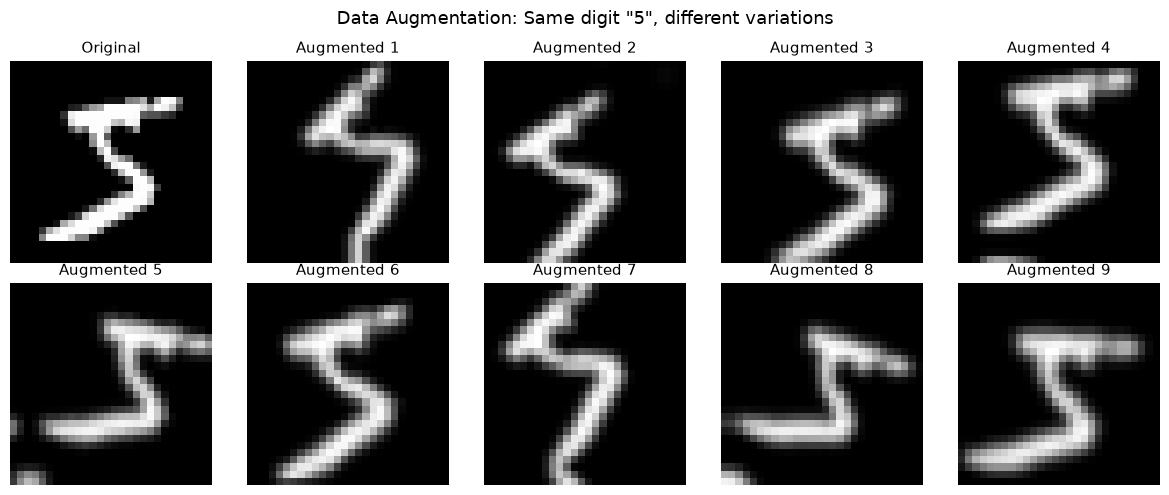

Each augmented version is a valid training example!
The model learns that these are all the same digit.


In [19]:
# Demonstrate data augmentation visually

# Define augmentation (careful with digits - no horizontal flip!)
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.1),          # Small rotation OK for digits
    layers.RandomZoom(0.1),              # Small zoom OK
    layers.RandomTranslation(0.1, 0.1),  # Small shift OK
])

# Take one sample image
sample_image = X_train[0:1]  # Shape: (1, 28, 28, 1)

# Show original and augmented versions
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# First image is original
axes[0, 0].imshow(sample_image[0, :, :, 0], cmap='gray')
axes[0, 0].set_title('Original', fontsize=11)
axes[0, 0].axis('off')

# Rest are augmented versions
for i, ax in enumerate(axes.flat[1:]):
    augmented = data_augmentation(sample_image, training=True)
    ax.imshow(augmented[0, :, :, 0], cmap='gray')
    ax.set_title(f'Augmented {i+1}', fontsize=11)
    ax.axis('off')

plt.suptitle(f'Data Augmentation: Same digit "{y_train[0]}", different variations', fontsize=13)
plt.tight_layout()
plt.show()

print("Each augmented version is a valid training example!")
print("The model learns that these are all the same digit.")

In [20]:
# Data augmentation on a REAL flower (flip is fine for flowers - unlike digits!)
if FLOWERS_READY:
    flower_aug = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ])

    images, labels = next(iter(train_ds))
    sample = images[0:1]                       # one flower, shape (1, H, W, 3)

    plt.figure(figsize=(14, 6))
    ax = plt.subplot(2, 5, 1)
    ax.imshow(sample[0].numpy().astype("uint8"))
    ax.set_title(f"Original: {class_names[int(labels[0])]}", fontsize=11)
    ax.axis("off")
    for i in range(2, 11):
        aug = flower_aug(sample, training=True)
        ax = plt.subplot(2, 5, i)
        ax.imshow(tf.clip_by_value(aug[0], 0, 255).numpy().astype("uint8"))
        ax.set_title(f"Augmented {i-1}", fontsize=11)
        ax.axis("off")
    plt.suptitle("One flower -> many training examples (flip, rotate, zoom)", fontsize=14)
    plt.tight_layout()
    plt.show()
    print("Every version is still the same flower - free extra training data!")
else:
    print("Set DATA_DIR and upload the flowers first (see the config cell).")


Set DATA_DIR and upload the flowers first (see the config cell).


## The Complete Flower Model - Training Is Your Exercise

You now have every piece: real images loaded from folders, augmentation, and the CNN
building blocks. The cell below assembles them into a full flower classifier and prints
its summary. We stop at the summary on purpose - **training it is your exercise.**

In [21]:
# Build a flower CNN (RGB, 14 classes) - then hand off: TRAINING is your exercise
if FLOWERS_READY:
    num_classes = len(class_names)

    flower_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ])

    flower_model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),   # RGB = 3 channels
        flower_augmentation,           # augmentation (active only during training)
        layers.Rescaling(1.0 / 255),   # normalize 0-255 -> 0-1

        # Three conv blocks (patterns get more complex, maps get smaller)
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPool2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPool2D(),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.MaxPool2D(),

        # Classification head
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),           # helps prevent overfitting
        layers.Dense(num_classes, activation="softmax"),
    ])

    flower_model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",   # integer labels (label_mode='int')
        metrics=["accuracy"],
    )

    print(f"Flower CNN for {num_classes} classes:")
    flower_model.summary()
    print("\nThe architecture is ready. TRAINING IT is your exercise:")
    print("  flower_model.fit(train_ds, validation_data=val_ds, epochs=15)")
    print("Then evaluate it with the same tools as Part 7 (confusion matrix, report).")
else:
    print("Set DATA_DIR and upload the flowers first (see the config cell).")


Set DATA_DIR and upload the flowers first (see the config cell).


---

# Part 7: Model Evaluation for Multi-Class

You've built and trained a CNN. The training curves looked good. But **how do you really know if your model works?**

So far, we've judged our models with a single accuracy number. But with 10 classes (or 14 flowers, or 100 medical conditions), we need more detailed analysis:

- **Which classes does the model confuse?** (Maybe it thinks 4s look like 9s)
- **Is the model equally good at all classes?** (Maybe it's great at "cat" but terrible at "bird")
- **What do the mistakes look like?** (Are they genuinely hard cases?)

Let's learn the tools to answer these questions:

- **Confusion Matrix:** Which classes get confused with each other?
- **Per-class metrics:** Precision, Recall, F1 for each class
- **Visualize mistakes:** See what the model gets wrong

---

## Confusion Matrix

```
CONFUSION MATRIX (10 classes):

                        PREDICTED CLASS
                    0   1   2   3   4   5   6   7   8   9
                  ┌───┬───┬───┬───┬───┬───┬───┬───┬───┬───┐
              0   │980│  0│  0│  0│  0│  0│  0│  0│  0│  0│  ← 980 zeros predicted correctly
                  ├───┼───┼───┼───┼───┼───┼───┼───┼───┼───┤
              1   │  0│1133│ 1│  0│  0│  0│  0│  1│  0│  0│  ← 1 one mistaken for 2
                  ├───┼───┼───┼───┼───┼───┼───┼───┼───┼───┤
  ACTUAL     2   │  1│  1│1025│ 0│  1│  0│  1│  2│  1│  0│
  CLASS           ├───┼───┼───┼───┼───┼───┼───┼───┼───┼───┤
              3   │  0│  0│  1│1004│ 0│  2│  0│  2│  1│  0│
                  ├───┼───┼───┼───┼───┼───┼───┼───┼───┼───┤
             ...  │                    ...                  │
                  └───┴───┴───┴───┴───┴───┴───┴───┴───┴───┘

READING THE MATRIX:
    • Diagonal = CORRECT predictions (we want these HIGH)
    • Off-diagonal = MISTAKES (we want these LOW)
    • Row = all images of that true class
    • Column = all predictions of that class

INSIGHTS:
    • Large off-diagonal number = common confusion
    • Example: If [4,9] is high, model confuses 4s for 9s
    • This makes sense - 4 and 9 can look similar!
```

---

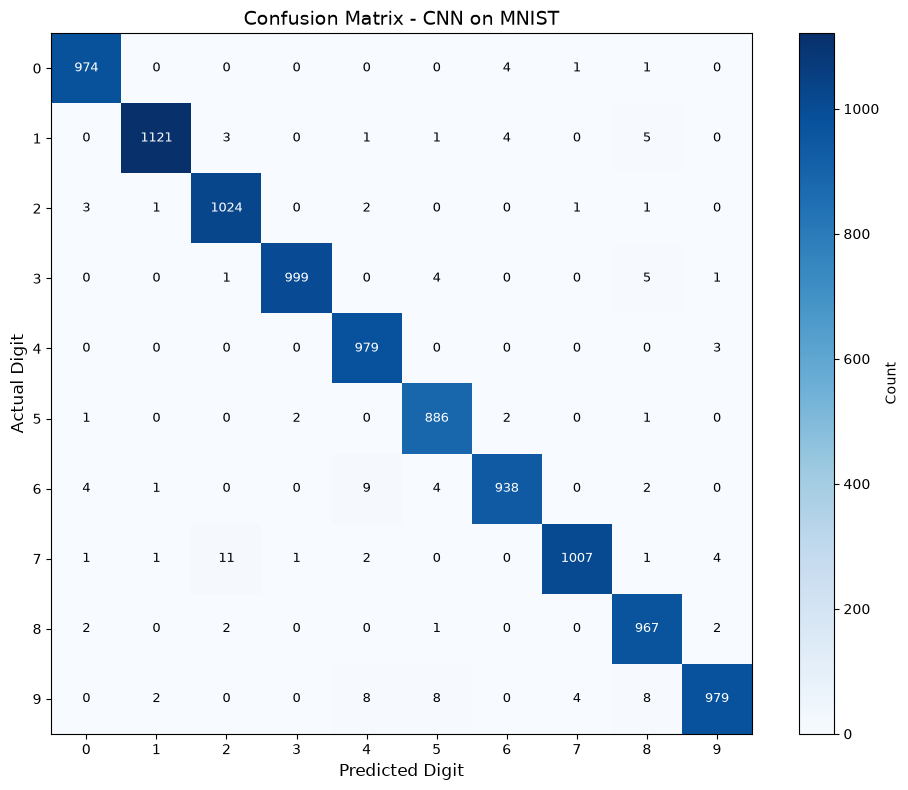

READING THIS MATRIX:
  • Diagonal values (dark blue) = correct predictions
  • Off-diagonal values = mistakes
  • Look for patterns: which digits get confused?


In [22]:
# Generate predictions for the test set
y_pred_probs = model_cnn.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert probabilities to class labels

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues')
plt.colorbar(label='Count')

# Add numbers to cells
for i in range(10):
    for j in range(10):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        plt.text(j, i, cm[i, j], ha='center', va='center', color=color, fontsize=9)

plt.xlabel('Predicted Digit', fontsize=12)
plt.ylabel('Actual Digit', fontsize=12)
plt.title('Confusion Matrix - CNN on MNIST', fontsize=14)
plt.xticks(range(10))
plt.yticks(range(10))
plt.tight_layout()
plt.show()

print("READING THIS MATRIX:")
print("  • Diagonal values (dark blue) = correct predictions")
print("  • Off-diagonal values = mistakes")
print("  • Look for patterns: which digits get confused?")

In [23]:
# Classification report: Precision, Recall, F1 for each class

print("CLASSIFICATION REPORT")
print("=" * 65)
print(classification_report(y_test, y_pred, digits=3))
print("=" * 65)
print("\nKEY METRICS EXPLAINED:")
print("  precision: When model predicts '5', how often is it correct?")
print("  recall:    Of all actual '5's, how many did we find?")
print("  f1-score:  Balance of precision and recall")
print("  support:   Number of actual samples of each class")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0      0.989     0.994     0.991       980
           1      0.996     0.988     0.992      1135
           2      0.984     0.992     0.988      1032
           3      0.997     0.989     0.993      1010
           4      0.978     0.997     0.987       982
           5      0.980     0.993     0.987       892
           6      0.989     0.979     0.984       958
           7      0.994     0.980     0.987      1028
           8      0.976     0.993     0.984       974
           9      0.990     0.970     0.980      1009

    accuracy                          0.987     10000
   macro avg      0.987     0.987     0.987     10000
weighted avg      0.987     0.987     0.987     10000


KEY METRICS EXPLAINED:
  precision: When model predicts '5', how often is it correct?
  recall:    Of all actual '5's, how many did we find?
  f1-score:  Balance of precision and recall
  support:   Number of actual sa

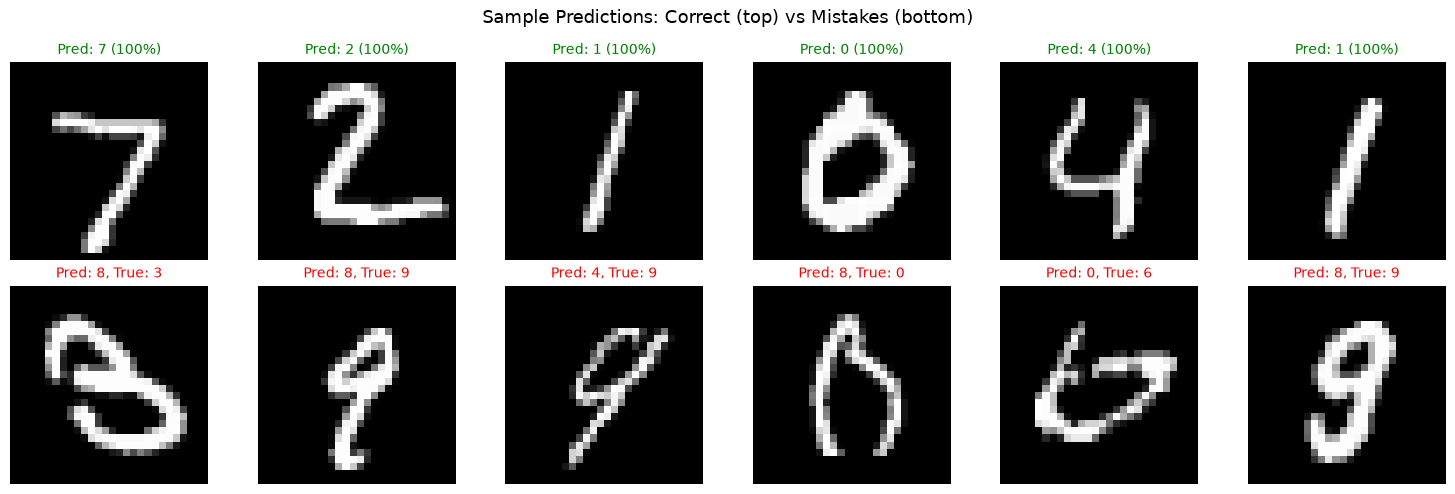

Total mistakes: 126 out of 10000 (1.26%)

Look at the mistakes - many are genuinely hard to read!


In [24]:
# Visualize some correct and incorrect predictions

# Find misclassified images
misclassified_idx = np.where(y_pred != y_test)[0]
correct_idx = np.where(y_pred == y_test)[0]

fig, axes = plt.subplots(2, 6, figsize=(15, 5))

# Top row: Correct predictions
for i in range(6):
    idx = correct_idx[i]
    axes[0, i].imshow(X_test[idx, :, :, 0], cmap='gray')
    prob = y_pred_probs[idx, y_pred[idx]]
    axes[0, i].set_title(f'Pred: {y_pred[idx]} ({prob:.0%})', color='green', fontsize=10)
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Correct', fontsize=12, color='green')

# Bottom row: Mistakes
for i in range(6):
    if i < len(misclassified_idx):
        idx = misclassified_idx[i]
        axes[1, i].imshow(X_test[idx, :, :, 0], cmap='gray')
        prob = y_pred_probs[idx, y_pred[idx]]
        axes[1, i].set_title(f'Pred: {y_pred[idx]}, True: {y_test[idx]}', color='red', fontsize=10)
    axes[1, i].axis('off')
axes[1, 0].set_ylabel('Mistakes', fontsize=12, color='red')

plt.suptitle('Sample Predictions: Correct (top) vs Mistakes (bottom)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Total mistakes: {len(misclassified_idx)} out of {len(y_test)} ({len(misclassified_idx)/len(y_test)*100:.2f}%)")
print("\nLook at the mistakes - many are genuinely hard to read!")

---

# Summary: What We Learned Today

Let's trace the story we just told:

**The Problem:** Dense networks (from Days 1-2) struggle with images because they flatten pixels into a 1D list, losing spatial structure and requiring millions of parameters.

**The Solution:** CNNs use three clever tricks:
1. **Local connectivity** - look at small regions instead of all pixels
2. **Weight sharing** - same filter slides everywhere
3. **Hierarchical learning** - simple patterns combine into complex ones

**The Building Blocks:**
- `Conv2D` - slides filters to detect patterns
- `MaxPool2D` - shrinks size, keeps important info
- `Flatten` - bridges to Dense classification

**The Results:** On MNIST, CNN beat Dense by ~2% accuracy - doesn't sound like much, but that's nearly 60% fewer errors!

```
┌─────────────────────────────────────────────────────────────────────┐
│  DEEP LEARNING DAY 3 - KEY TAKEAWAYS                               │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  1. WHY CNNs FOR IMAGES?                                           │
│     • Dense networks flatten images, losing spatial structure      │
│     • CNNs use local connectivity (look at 3×3 regions)           │
│     • CNNs use weight sharing (same filter everywhere)            │
│     • Result: Fewer parameters, better accuracy!                   │
│                                                                     │
│  2. CNN BUILDING BLOCKS                                            │
│     • Conv2D: Learn local patterns (edges, textures, shapes)      │
│     • MaxPool2D: Reduce size, keep important features             │
│     • Flatten: Convert 2D→1D for classification                   │
│     • Dense: Final classification (same as Day 1!)                │
│                                                                     │
│  3. MULTI-CLASS CLASSIFICATION                                     │
│     • Output: Dense(num_classes, activation='softmax')            │
│     • Loss: categorical_crossentropy or sparse_categorical        │
│     • Softmax outputs probabilities that sum to 1                  │
│                                                                     │
│  4. LOADING IMAGE DATA                                             │
│     • image_dataset_from_directory() for folder structures        │
│     • Automatic resizing, batching, label encoding                │
│                                                                     │
│  5. DATA AUGMENTATION                                              │
│     • Create variations: flip, rotate, zoom, shift                │
│     • Prevents overfitting, improves generalization               │
│     • Only active during training!                                │
│                                                                     │
│  6. EVALUATION                                                     │
│     • Confusion matrix: Which classes get confused?               │
│     • Precision/Recall/F1: Per-class performance                  │
│     • Always visualize predictions to understand errors!          │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

### 🎮 Keep Exploring!

The **Convolution Explorer app** will help reinforce these concepts. Try:
- Experimenting with different kernels to see what patterns they detect
- Running the VGG16 simulation to see a full CNN in action
- Comparing CNN vs Dense parameters at different image sizes

```bash
cd convolution_explorer && python main.py
```

---

## Connecting to Your Exercises

```
┌─────────────────────────────────────────────────────────────────────┐
│  DAILY CHALLENGE: MNIST                                            │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  You just did most of it! Your task:                               │
│    1. Build Dense network (we did this)                            │
│    2. Build CNN (we did this)                                      │
│    3. Compare performance (we did this!)                           │
│                                                                     │
│  Try experimenting with:                                           │
│    • More Conv2D layers                                            │
│    • More filters (64, 128)                                        │
│    • Dropout for regularization                                    │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  FLOWER CLASSIFICATION EXERCISE                                     │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  Same concepts, real images!                                       │
│                                                                     │
│  KEY DIFFERENCES FROM MNIST:                                       │
│    • RGB images (3 channels, not 1)                                │
│    • Larger images (resize to 128×128 or 256×256)                  │
│    • 14 classes (flowers) instead of 10 (digits)                   │
│    • Load with image_dataset_from_directory()                      │
│                                                                     │
│  YOUR WORKFLOW:                                                    │
│    1. Load data: image_dataset_from_directory()                    │
│    2. Visualize samples (always look at your data!)                │
│    3. Build CNN: Conv2D → Pool → Conv2D → Pool → Flatten → Dense   │
│    4. Add augmentation: RandomFlip, RandomRotation, RandomZoom     │
│    5. Train with validation                                        │
│    6. Evaluate: confusion matrix, classification report            │
│                                                                     │
│  TIPS:                                                             │
│    • Start simple (2 Conv blocks), add complexity if needed        │
│    • Use data augmentation - it really helps!                      │
│    • Watch for overfitting (val_loss increasing)                   │
│    • Add Dropout(0.5) before final Dense if overfitting            │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

---

# Appendix: Complete CNN Template for Flower Exercise

---

---

# You Did It! 🎉

You just learned the architecture that revolutionized computer vision. The same ideas in this notebook - convolution, pooling, hierarchical features - power billion-dollar products at Google, Apple, Tesla, and beyond.

## Key Takeaways

- **Always visualize your data** before building models
- **Start simple**, add complexity only if needed
- **Use data augmentation** - it really helps with small datasets!
- **Check the confusion matrix** to understand what's being confused
- **Experiment!** Try different architectures, see what works best

## What's Next?

Your exercises will give you hands-on practice with:
- The **MNIST challenge** (extend what we built today)
- **Flower classification** (real RGB images, folder loading, augmentation)

And in future sessions, you'll learn **Transfer Learning** - using pre-trained networks (like VGG16) as a starting point for your own tasks. Why train from scratch when someone already trained on millions of images?

## Keep the Convolution Explorer Running!

The app isn't just for this lecture - use it whenever you want to refresh your understanding of:
- How convolution actually works (watch the kernel slide!)
- What different filters detect
- Why MaxPooling reduces size
- How augmentation creates variations

```bash
cd convolution_explorer && python main.py
```

**Now go build something amazing!** 🚀

---